In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import model_qagent as model

# Experiment 1: Agent Parameters

In [2]:
default_rewards = {i: 1 for i in range(100)}
default_rewards[0] = -10

In [3]:
ex = model.Memory(100, 5, default_rewards, mean_s=0, trauma=(0, -10))
print(ex.graph.nodes())

[[1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1], [1]]


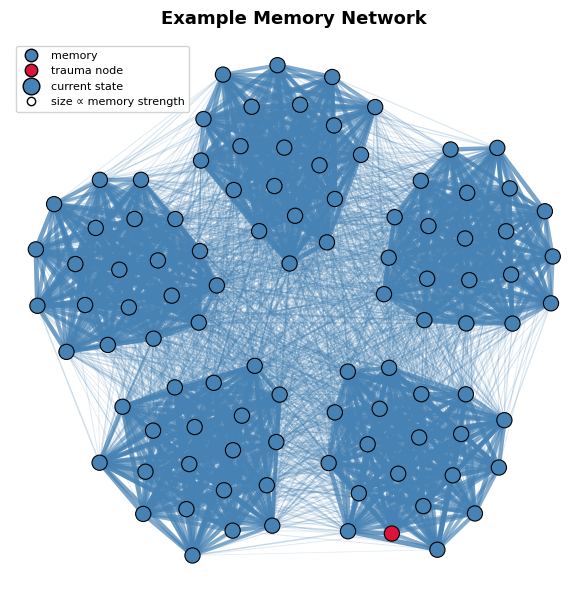

In [4]:
ex.visualize("Example Memory Network", min_strength=0.1)

In [ ]:
ex.add_memories(10)
ex.visualize()

Trauma encountered in 36/100 retrievals (36.0%)
32
20
46
20
65
80
82
20
7
40
73
100
21
20
97
100
100
51
77
100
55
70
50
41
70
100
97
100
100
72
100
100
47
10
55
23
52
89
17
100
100
95
100
100
60
100
100
53
100
100
100
100
100
100
52
100
100
100
100
100
100
100
87
100
100
100
100
47
18
100
38
100
24
100
100
100
8
100
100
38
100
71
100
100
100
100
100
100
41
100
100
100
100
8
100
100
29
100
100
100


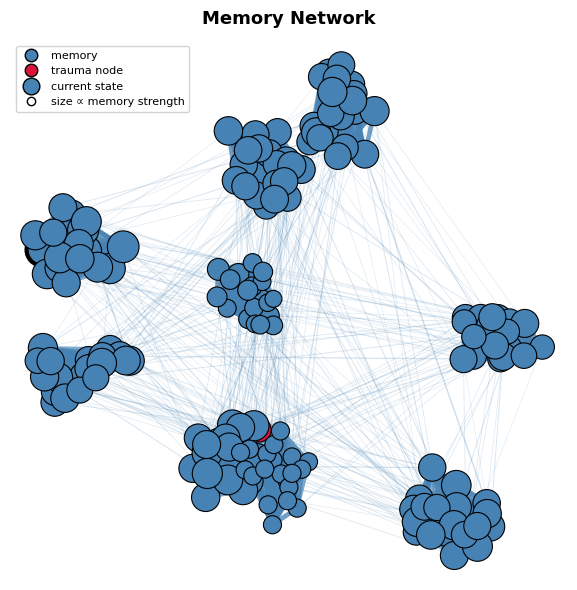

In [5]:
environment = model.Memory(100, 5, default_rewards, trauma=(0, 10))
agent = model.QAgent(environment)
test = model.Simulator(agent, environment)
test.run(100, 100, time=5, print_message=True, delta=20, a=0.5)
for trial in test.record:
    print(len(trial))
test.network.visualize(min_strength=1)

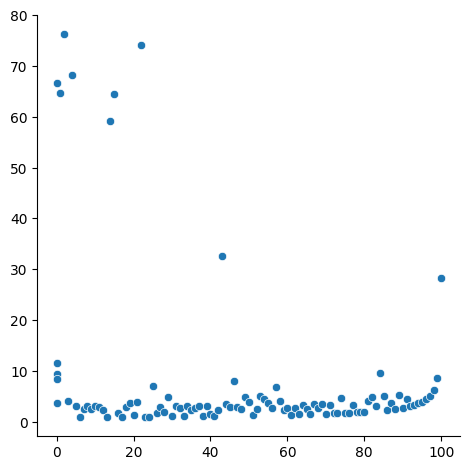

In [12]:
data = test.network.group_activation()
xs = [0, 0, 0, 0] + list(data.keys())[:101]
ys = list(data.values())
sns.relplot(x=xs, y=ys, kind="scatter")
plt.show()

In [ ]:
def exp_1(opt, params, n, rep=10):
    avg_retrieval = []
    final_retrieval = []
    for p in params:
        rep_avg = []
        rep_final = []
        for _ in range(rep):
            if opt == "alpha":
                agent = model.Agent(alpha=p)
            elif opt == "gamma":
                agent = model.Agent(gamma=p)
            elif opt == "temp":
                agent = model.Agent(temp=p)
            environment = model.Memory(100, 5, default_rewards, trauma=(0, 1))
            test = model.Simulator(agent, environment)
            test.run(n, 100, time=0.1, delta=20, a=10)
            retrieval_length = [len(trial) for trial in test.record]
            rep_avg.append(np.mean(retrieval_length))
            rep_final.append(retrieval_length[-1])
        avg_retrieval.append(np.mean(rep_avg))
        final_retrieval.append(np.mean(rep_final))
    return avg_retrieval, final_retrieval

fig, axs = plt.subplots(3, 2, sharey=True)
alphas = [n / 100 for n in range(1, 21)]
gammas = [n / 100 for n in range(80, 100)]
temps = [n / 100 for n in range(1, 21)]
ax_count = 0
for opt, params in {"alpha": alphas, "gamma": gammas, "temp": temps}.items():
    avg_retrieval, final_retrieval = exp_1(opt, params, 50, rep=10)
    sns.lineplot(x=params, y=avg_retrieval, ax=axs[ax_count][0])
    sns.lineplot(x=params, y=final_retrieval, ax=axs[ax_count][1])
    axs[ax_count][0].set_xlabel(opt)
    axs[ax_count][1].set_xlabel(opt)
    ax_count += 1
fig.suptitle("Average and Final Retrieval Lengths")
plt.tight_layout()
plt.show()

# Experiment 2: Environment Parameters

In [ ]:
def exp_2(n, groups, max_length, runs=100, time=0.1, rewards=None):
    agent = model.Agent()
    if rewards is None:
        rewards = {i: 1 for i in range(n)}
        rewards[0] = -10
    environment = model.Memory(n, groups, rewards, trauma=(0, 1))
    test = model.Simulator(agent, environment)
    test.run(runs, max_length, time=time, delta=20, a=10)
    retrieval_length = [len(trial) for trial in test.record]
    return retrieval_length

In [ ]:
data = []
groups = 10
for i, n in enumerate([50, 100, 150, 200, 250]):
    rewards = {i: 1 for i in range(n)}
    for _ in range(i):
        rewards[_] = -10
    lengths = exp_2(n, groups, max_length=n - 1, rewards=rewards)
    for length in lengths:
        data.append({"n": n, "value": length / n})
sns.catplot(data=pd.DataFrame(data), x="n", y="value", kind="bar")
plt.title(f"Percent of total memories retrieved for varying numbers of memories (number of groups constant)")
plt.show()

In [ ]:
data = []
for i, n in enumerate([50, 100, 150, 200, 250]):
    rewards = {i: 1 for i in range(n)}
    groups = n // 10
    for _ in range(i):
        rewards[_] = -10
    lengths = exp_2(n, groups, max_length=n - 1, rewards=rewards)
    for length in lengths:
        data.append({"n": n, "value": length / n})
sns.catplot(data=pd.DataFrame(data), x="n", y="value", kind="bar")
plt.title(f"Percent of total memories retrieved for varying number of memories (group size constant)")
plt.show()

In [ ]:
data = []
n = 100
groups = 10
for t in [0.1, 1, 10, 100]:
    lengths = exp_2(n, groups, max_length=n - 1, time=t)
    avg = np.mean(lengths)
    final = lengths[-1]
    data.append({"time": t, "type": "average", "value": avg / n})
    data.append({"time": t, "type": "final", "value": final / n})
sns.catplot(data=pd.DataFrame(data), x="time", y="value", hue="type", kind="bar")
plt.title(f"Percent of total memories retrieved for {n} memories and {groups} groups")
plt.show()

In [ ]:
data = []
groups = 10
n = 100
rewards = {i: 1 for i in range(n)}
rewards1 = rewards.copy()
rewards2 = rewards.copy()
rewards3 = rewards.copy()
rewards4 = rewards.copy()
rewards1[0] = -10
rewards2[0] = -100
for i in range(5):
    rewards3[i] = -10
    rewards4[i] = -100
for r, name in zip([rewards1, rewards2, rewards3, rewards4], ["r1", "r2", "r3", "r4"]):
    lengths = exp_2(n, groups, max_length=n - 1, time=0.1, rewards=r)
    avg = np.mean(lengths)
    final = lengths[-1]
    data.append({"reward": name, "type": "average", "value": avg / n})
    data.append({"reward": name, "type": "final", "value": final / n})
sns.catplot(data=pd.DataFrame(data), x="reward", y="value", hue="type", kind="bar")
plt.title(f"Percent of total memories retrieved for {n} memories and {groups} groups")
plt.show()